In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn import metrics

In [2]:
# Load AHS data and select potentially useful columns. 
# AHS sample is largely the same year-to-year, so combining years doesn't make sense.
# We're not making year-over-year comparsions here, so only the 2021 data is currently being used. 
# 2021 data chosen because the 2023 response rate was abnormally low,
# so 2021 is most recent year with a healthy response rate.

# If other years' data is needed, uncomment the relevant rows and add ahs____ to ahs_dfs list below.

# ahs2015 = pd.read_csv('./csv/ahs2015n.csv')
# ahs2017 = pd.read_csv('./csv/ahs2017n.csv')
# ahs2019 = pd.read_csv('./csv/ahs2019n.csv')
ahs2021 = pd.read_csv('./csv/ahs2021n.csv')
# ahs2023 = pd.read_csv('./csv/ahs2023n.csv')

ahs_fields = ['CONTROL', 'WEIGHT', 'DIVISION', 'OMB13CBSA', 'BLD', 'YRBUILT', 'TENURE', 'VACANCY', 'GARAGE', 'LOTSIZE',
        'BEDROOMS', 'BATHROOMS', 'DINING', 'KITCHENS', 'LAUNDY', 'FINROOMS', 'UFINROOMS', 'TOTROOMS', 'STORIES',
        'UNITFLOORS', 'UNITSIZE', 'HSHLDTYPE', 'NUMADULTS', 'NUMOLDKIDS', 'NUMYNGKIDS', 'HHAGE', 'HHCITSHP', 'HHMOVE',
        'HHRACE', 'HHSEX', 'HHGRAD', 'HINCP', 'MORTAMT', 'PROTAXAMT', 'INSURAMT', 'HOAAMT', 'LOTAMT', 'RENT', 'MAINTAMT',
        'UTILAMT', 'TOTHCAMT', 'HOWBUY', 'MARKETVAL'
        ]

# ahs2015 = ahs2015[ahs_fields]
# ahs2017 = ahs2017[ahs_fields]
# ahs2019 = ahs2019[ahs_fields]
ahs2021 = ahs2021[ahs_fields]
# ahs2023 = ahs2023[ahs_fields]

# Add any additional years being used here.
ahs_dfs = [ahs2021]

# Remove redundant quoting from string fields
for df in ahs_dfs:
    for field in ahs_fields:
        if str(df.dtypes[field]) == 'str':
            df[field] = df[field].str.strip("'")

In [3]:
# SOC data covers different newly-constructed homes each year, so we can combine multiple years to get a bigger sample.

soc2020 = pd.read_csv('./csv/soc20.csv')
soc2021 = pd.read_csv('./csv/soc21.csv')
soc2022 = pd.read_csv('./csv/soc22.csv')
soc2023 = pd.read_csv('./csv/soc23.csv')
soc2024 = pd.read_csv('./csv/soc24.csv')

soc2020['SOC_YEAR'] = '2020'
soc2021['SOC_YEAR'] = '2021'
soc2022['SOC_YEAR'] = '2022'
soc2023['SOC_YEAR'] = '2023'
soc2024['SOC_YEAR'] = '2024'

# Select only the fields we need for direct comparion to AHS.
soc_fields = ['WEIGHT', 'SOC_YEAR', 'CAT', 'DET', 'DIV', 'STOR', 'BEDR',
              'FULB', 'HAFB', 'SQFS']

soc2020 = soc2020[soc_fields]
soc2021 = soc2021[soc_fields]
soc2022 = soc2022[soc_fields]
soc2023 = soc2023[soc_fields]
soc2024 = soc2024[soc_fields]

soc_all = pd.concat([soc2020, soc2021, soc2022, soc2023, soc2024])

print("2020-2024 SOC dataframe shapes:")
print(f"SOC 2020: {soc2020.shape}")
print(f"SOC 2021: {soc2021.shape}")
print(f"SOC 2022: {soc2022.shape}")
print(f"SOC 2023: {soc2023.shape}")
print(f"SOC 2024: {soc2024.shape}")
print(f"SOC combined: {soc_all.shape}")

2020-2024 SOC dataframe shapes:
SOC 2020: (25526, 10)
SOC 2021: (26518, 10)
SOC 2022: (26581, 10)
SOC 2023: (25885, 10)
SOC 2024: (25721, 10)
SOC combined: (130231, 10)


In [4]:
# Clean and prepare SOC data for affordability classification.

soc_df = soc_all[soc_all['DET'] != 0]
soc_df = soc_df[soc_df['SQFS'] != 0]
soc_df = soc_df[soc_df['BEDR'] != 0]
soc_df = soc_df[soc_df['FULB'] != 9]
soc_df = soc_df[soc_df['HAFB'] != 9]
soc_df = soc_df[soc_df['STOR'] != 0]

In [5]:
# SOC to AHS Transformation Functions

# SOC and AHS contain many simlar fields but they often differ in formatting (continuous vs. binned, bin ranges, etc).
# SOC data rows need to have column naming and formatting like AHS so we can use it with a model trained on AHS data.

def map_soc_division(div_code):
    # Map SOC DIV to AHS DIVISION (Census Division codes 1-9)
    return str(int(div_code))

def map_soc_bedrooms(bedr):
    # Map SOC BEDR to AHS BEDROOMS format
    return int(bedr)

def map_soc_bathrooms(fulb, hafb):
    # Convert SOC full and half bathrooms to AHS BATHROOMS format
    # SOC FULB/HAFB are categorical: 1=1 or less, 2=2, 3=3, 4=4 or more, 9=not reported
    # AHS BATHROOMS: 01=1 full, 02=1.5, 03=2 full, 04=2.5, 05=3 full, 06=3+ full, 13=not reported
    
    fulb = int(fulb)
    hafb = int(hafb)
    
    # If either fulb or hafb is 9 (not reported), return '13'
    if fulb == 9 and hafb == 9:
        return '13'
    
    # Map based on FULB and HAFB combinations
    if fulb == 1:
        if hafb == 0 or hafb == 9:
            return '01'  # One full bathroom
        else:
            return '02'  # More than one half baths = 1.5 bathrooms
    elif fulb == 2:
        if hafb == 0 or hafb == 9:
            return '03'  # 2.5 bathrooms
        else:
            return '04'  # More than one half baths = 2.5 bathrooms
    elif fulb == 3:
        if hafb == 0 or hafb == 9:
            return '05'  # 3 full bathrooms
        else:
            return '06'  # More than one half baths = round up to 3+
    elif fulb == 4:
        return '06'  # More than 3 full bathrooms

def map_soc_building_type(det):
    # Map SOC CAT to AHS BLD (Building Type)
    # SOC DET: 1=Detached, 2=Attached, 0=Not reported
    # AHS BLD: 02=One-family detached, 03=One-family attached
    
    det = int(det)
    
    # For SOC data (newly constructed homes), all are single-family.
    # DET determines detached vs attached
    if det == 2:
        return '03'  # One-family house, attached
    else:
        return '02'  # Default to detached

def map_soc_unitfloors(stor):
    # Map SOC STOR (stories) to AHS UNITFLOORS
    # SOC STOR: 1=1 story, 2=2 or more stories (including 1½), 3=Split-level, 0=Not reported
    # AHS UNITFLOORS: 01=One floor, 02=Two floors, 03=Three or more floors
    
    stor = int(stor)
    
    if stor == 1:
        return 1  # One floor
    elif stor == 2:
        return 2  # Two floors
    elif stor == 3:
        return 3  # 3 or more floors
    else:  # stor == 0 (not reported)
        return 1  # Default to one floor

def map_soc_unitsize(sqfs):
    # Map SOC SQFS to AHS UNITSIZE format
    sqfs = int(sqfs)
    
    if sqfs < 500:
        return '1'
    elif sqfs < 750:
        return '2'
    elif sqfs < 1000:
        return '3'
    elif sqfs < 1500:
        return '4'
    elif sqfs < 2000:
        return '5'
    elif sqfs < 2500:
        return '6'
    elif sqfs < 3000:
        return '7'
    elif sqfs < 4000:
        return '8'
    else:
        return '9'

In [6]:
# Apply transformation functions to SOC data to create AHS-compatible derived columns

soc_df['DIVISION'] = soc_df['DIV'].apply(map_soc_division)
soc_df['BEDROOMS'] = soc_df['BEDR'].apply(map_soc_bedrooms)
soc_df['BATHROOMS'] = soc_df.apply(lambda row: map_soc_bathrooms(row['FULB'], row['HAFB']), axis=1)
soc_df['BLD'] = soc_df['DET'].apply(map_soc_building_type)
soc_df['UNITFLOORS'] = soc_df['STOR'].apply(map_soc_unitfloors)
soc_df['UNITSIZE'] = soc_df['SQFS'].apply(map_soc_unitsize)
soc_df['AGE'] = 0 # Assume that all houses in SOC are new-build, so set age to 0.

soc_df.reset_index(inplace=True)

In [7]:
# Function for pre-calculating boxplot values using weights

def get_bxpstats(fieldname, cat, log=False):
    df, label = cat
    sum_weight = df['WEIGHT'].sum()
    q1_wt = sum_weight / 4
    q2_wt = sum_weight / 2
    q3_wt = 3 * sum_weight / 4

    df = df.sort_values(by=fieldname, inplace=False)
    if log:
        df[fieldname] = np.log10(df[fieldname])
    df['CW'] = df['WEIGHT'].cumsum()
    df[f'{fieldname}_SCALED'] = df[fieldname] * (df['WEIGHT'] / sum_weight)

    q1 = df[df['CW'] >= q1_wt].iloc[0][fieldname]
    q2 = df[df['CW'] >= q2_wt].iloc[0][fieldname]
    q3 = df[df['CW'] >= q3_wt].iloc[0][fieldname]

    iqr = q3 - q1
    whis_min = q1 - (1.5 * iqr)
    whis_max = q3 + (1.5 * iqr)

    weighted_mean = df[f'{fieldname}_SCALED'].sum()

    whis_low = df[df[fieldname] >= whis_min].iloc[0][fieldname]
    whis_high = df[df[fieldname] <= whis_max].iloc[-1][fieldname]

    fliers = df[(df[fieldname] > whis_high) | (df[fieldname] < whis_low)][fieldname]

    return {'med': q2, 'q1': q1, 'q3': q3, 'whislo': whis_low,
            'whishi': whis_high, 'fliers': fliers, 'label': label, 'mean': weighted_mean}

In [8]:
# Function for calculating weighted category counts, e.g. when computing weighted histogram bars.

def get_homecounts(df):
    sum_weight = df['WEIGHT'].sum()
    return sum_weight / 1000

In [9]:
# Function for estimating hypothetical monthly mortgate payments based on market value of a home.

def est_mortgage(marketval, rate=0.04, dpp = 0.2, term=30):
    if marketval == -6:
        return 0
    dp = np.ceil(dpp * marketval)
    p = marketval - dp
    r = rate / 12
    n = term * 12

    s = (1 + r) ** n
    return int(np.ceil(p * ((r * s) / (s - 1))))

In [10]:
# Build a clean dataframe for classification

# Only include the fields that we're actually using for cleaning or classification.
df = ahs2021[['WEIGHT', 'HINCP', 'TENURE', 'MARKETVAL', 'UNITSIZE', 'BEDROOMS', 'BATHROOMS', 'BLD', 'YRBUILT',
              'DIVISION', 'TOTHCAMT', 'MORTAMT', 'UNITFLOORS']]

# Only include owned or rented homes (exclude rent-free category)
df = df[(df['TENURE'] == '1') | (df['TENURE'] == '2')]

# Only include homes where monthly total housing cost is positive
df = df[df['TOTHCAMT'] > 0]

# Remove homes that are missing square-footage data
df = df[df['UNITSIZE'] != '-9']

# Remove homes that have no full bathroom
df = df[(df['BATHROOMS'] == '01') | (df['BATHROOMS'] == '02') | (df['BATHROOMS'] == '03') | (df['BATHROOMS'] == '04') | (df['BATHROOMS'] == '05') | (df['BATHROOMS'] == '06')]

# Remove mobile homes, boats, RVs, vans
df = df[(df['BLD'] != '10') & (df['BLD'] != '01')]

# Negative mortage amounts indicate not reported, not applicable, or (in rare cases) bundling of mortgage and insurance.
# Just floor these values to 0, since we are constructing our own estimated mortgage amounts.
df['MORTAMT'] = df['MORTAMT'].clip(lower=0)

In [11]:
# Add derived columns

df['AGE'] = 2022 - df['YRBUILT']

# PMORTAMT will be our estimation of what a new homebuyer would pay in montly mortgage payment
df['PMORTAMT'] = df['MARKETVAL'].apply(est_mortgage)

# Create new total monthly cost estimation using our estimated mortgage payment
df['PTOTHCAMT'] = df['TOTHCAMT'] - df['MORTAMT'] + df['PMORTAMT']

# Max monthly expenditure affordable to median income household on 30% of gross income
# Using 2021 US median gross income, as reported by US Census Bureau.
MEDIAN_HH_INCOME_2021 = 70784
AFFORDABLE_MONTHLY_MAX = int(np.ceil((MEDIAN_HH_INCOME_2021 / 12) * 0.3))

print(f'Maximum median income affordable montly spend: {AFFORDABLE_MONTHLY_MAX}')

df['AFFORDABLE'] = df['PTOTHCAMT'] <= AFFORDABLE_MONTHLY_MAX

Maximum median income affordable montly spend: 1770


All
{'med': np.int64(1270), 'q1': np.int64(770), 'q3': np.int64(1965), 'whislo': np.int64(10), 'whishi': np.int64(3757), 'fliers': 52633      3758
45121      3758
4183       3758
58681      3758
17841      3758
          ...  
12289     98229
51604    103154
37530    105264
37043    173782
10170    203093
Name: TOTHCAMT, Length: 2799, dtype: int64, 'label': 'All', 'mean': np.float64(1655.4992410843718)}
All, adjusted
{'med': np.int64(1668), 'q1': np.int64(1115), 'q3': np.int64(2514), 'whislo': np.int64(10), 'whishi': np.int64(4612), 'fliers': 34930     4613
45856     4614
18441     4614
48245     4614
42592     4614
         ...  
35145    46211
52190    46363
40487    47474
43061    55627
30402    58954
Name: PTOTHCAMT, Length: 3650, dtype: int64, 'label': 'All', 'mean': np.float64(2130.3125223137936)}
Owned
{'med': np.int64(1279), 'q1': np.int64(719), 'q3': np.int64(2077), 'whislo': np.int64(14), 'whishi': np.int64(4111), 'fliers': 30946      4115
29137      4116
46352      4117
6228

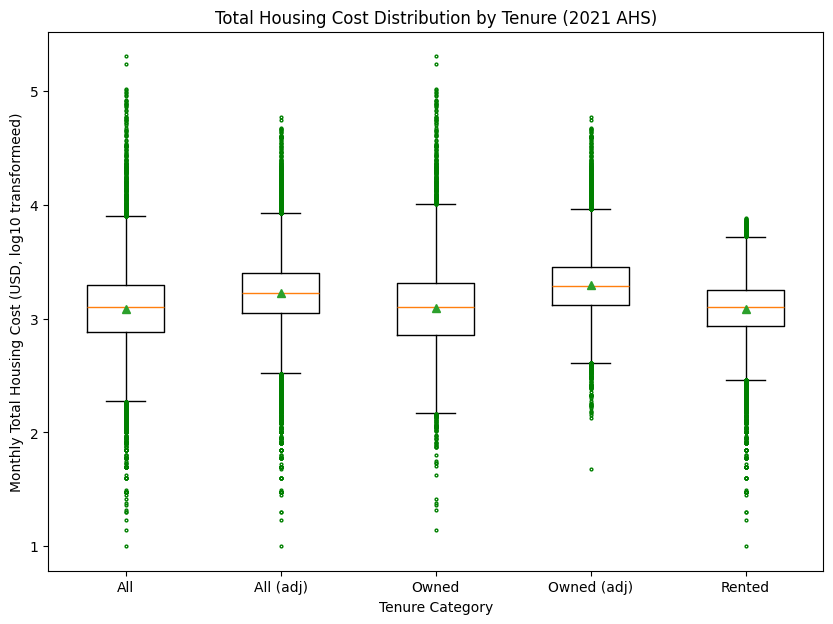

In [12]:
# Calculate some summary statisitics and plot so we can understand the impact of our mortgage adjustment

df_owned = df[df['TENURE'] == '1']
df_rented = df[df['TENURE'] == '2']

bp_all_no_log = median_all = get_bxpstats('TOTHCAMT', (df, 'All'))
bp_all_tr_no_log = median_all = get_bxpstats('PTOTHCAMT', (df, 'All'))
bp_owned_no_log = get_bxpstats('TOTHCAMT', (df_owned, 'Owned'))
bp_owned_tr_no_log = get_bxpstats('PTOTHCAMT', (df_owned, 'Owned'))
bp_rented_no_log = get_bxpstats('PTOTHCAMT', (df_rented, 'Rented'))

bp_all = get_bxpstats('TOTHCAMT', (df, 'All'), log=True)
bp_all_tr = get_bxpstats('PTOTHCAMT', (df, 'All (adj)'), log=True)
bp_owned = get_bxpstats('TOTHCAMT', (df_owned, 'Owned'), log=True)
bp_owned_tr = get_bxpstats('PTOTHCAMT', (df_owned, 'Owned (adj)'), log=True)
bp_rented = get_bxpstats('PTOTHCAMT', (df_rented, 'Rented'), log=True)

print('All')
print(bp_all_no_log)
print('All, adjusted')
print(bp_all_tr_no_log)
print('Owned')
print(bp_owned_no_log)
print('Owned, adjusted')
print(bp_owned_tr_no_log)
print('Rented')
print(bp_rented_no_log)

box_stats = [bp_all, bp_all_tr, bp_owned, bp_owned_tr, bp_rented]
flierprops = {'markersize': 4, 'marker': '.', 'markeredgecolor': 'green'}

fig, ax = plt.subplots(figsize=(10,7))
ax.bxp(box_stats, showfliers=True, flierprops=flierprops, showmeans=True)
plt.xlabel('Tenure Category')
plt.ylabel('Monthly Total Housing Cost (USD, log10 transformeed)')
_ = plt.title('Total Housing Cost Distribution by Tenure (2021 AHS)')

In [13]:
# Convert categorical fields to dummy variables (One-hot encoding)

ahs_mod = df.reset_index()

cat_fields = ahs_mod[['UNITSIZE', 'BATHROOMS', 'BLD', 'DIVISION', 'UNITFLOORS']]
other_fields = ahs_mod[['BEDROOMS', 'AGE', 'AFFORDABLE']]

oh_enc = OneHotEncoder(sparse_output=False)
result = oh_enc.fit_transform(cat_fields)

cat_fields = pd.DataFrame(result, columns = oh_enc.get_feature_names_out())

ahs_mod = pd.concat([cat_fields, other_fields], axis=1)

ahs_mod.dtypes

UNITSIZE_1      float64
UNITSIZE_2      float64
UNITSIZE_3      float64
UNITSIZE_4      float64
UNITSIZE_5      float64
UNITSIZE_6      float64
UNITSIZE_7      float64
UNITSIZE_8      float64
UNITSIZE_9      float64
BATHROOMS_01    float64
BATHROOMS_02    float64
BATHROOMS_03    float64
BATHROOMS_04    float64
BATHROOMS_05    float64
BATHROOMS_06    float64
BLD_02          float64
BLD_03          float64
BLD_04          float64
BLD_05          float64
BLD_06          float64
BLD_07          float64
BLD_08          float64
BLD_09          float64
DIVISION_1      float64
DIVISION_2      float64
DIVISION_3      float64
DIVISION_4      float64
DIVISION_5      float64
DIVISION_6      float64
DIVISION_7      float64
DIVISION_8      float64
DIVISION_9      float64
UNITFLOORS_1    float64
UNITFLOORS_2    float64
UNITFLOORS_3    float64
BEDROOMS          int64
AGE               int64
AFFORDABLE         bool
dtype: object

In [14]:
# Set up a train-test split for model validation
np.random.seed(2906)

n = ahs_mod.shape[0]
test_size = n // 5

ahs_mod_shuffled = ahs_mod.sample(n)

test = ahs_mod_shuffled[0:test_size]
train = ahs_mod_shuffled[~ahs_mod_shuffled.index.isin(test.index)]

test_X = test.drop(columns=['AFFORDABLE'])
test_y = test['AFFORDABLE']

train_X = train.drop(columns=['AFFORDABLE'])
train_y = train['AFFORDABLE']

In [15]:
log_c_vec = pd.Series(np.arange(-10, 10, 0.5))
c_vec = log_c_vec.rpow(10.0)

auc_scores_test = []
auc_scores_train = []
coefs = []
models = []

for cval in c_vec:
    model = LogisticRegression(solver='liblinear', l1_ratio=0.0, C=cval)
    model.fit(train_X, train_y)
    probs_train = model.predict_proba(train_X)
    probs_test = model.predict_proba(test_X)
    auc_train = metrics.roc_auc_score(train_y, probs_train[:, 1])
    auc_test = metrics.roc_auc_score(test_y, probs_test[:, 1])
    auc_scores_train.append(auc_train)
    auc_scores_test.append(auc_test)
    coefs.append(model.coef_[0])
    models.append(model)

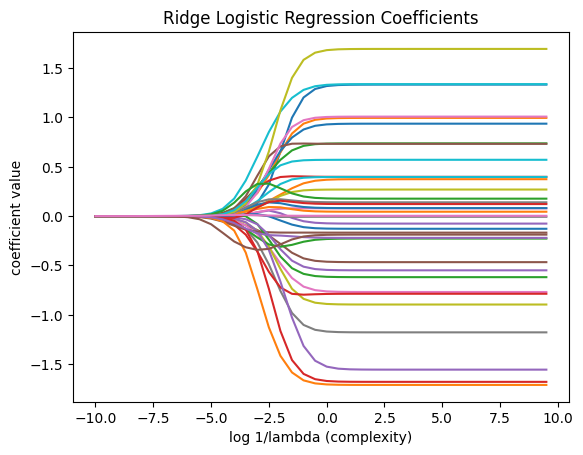

In [16]:
coefs = pd.DataFrame(coefs)

for idx in coefs:
    plt.plot(log_c_vec, coefs[idx])
plt.xlabel("log 1/lambda (complexity)")
plt.ylabel("coefficient value")
plt.title("Ridge Logistic Regression Coefficients")
plt.show()

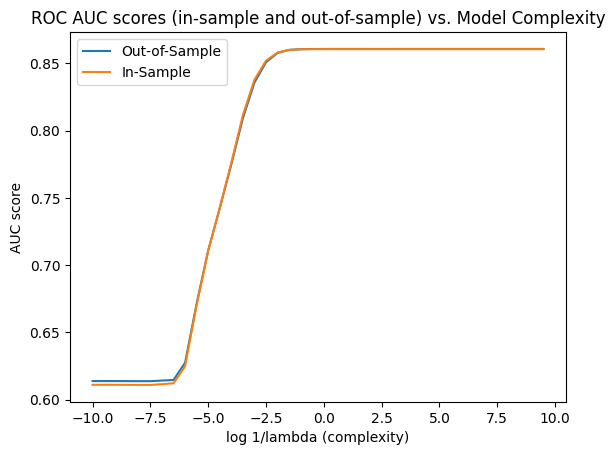

In [17]:
plt.plot(log_c_vec, auc_scores_test, label='Out-of-Sample')
plt.plot(log_c_vec, auc_scores_train, label='In-Sample')
plt.title("ROC AUC scores (in-sample and out-of-sample) vs. Model Complexity")
plt.xlabel("log 1/lambda (complexity)")
plt.ylabel("AUC score")
plt.legend()
plt.show()

In [18]:
max_auc_idx = np.argmax(auc_scores_test)
log_c_vec[max_auc_idx]

np.float64(2.5)

In [19]:
model = models[max_auc_idx]

train_pred = model.predict(train_X)
test_pred = model.predict(test_X)

train_probs = model.predict_proba(train_X)
test_probs = model.predict_proba(test_X)

Text(0.5, 1.0, 'Confusion Matrix for Predictions on Out-of-Sample Data')

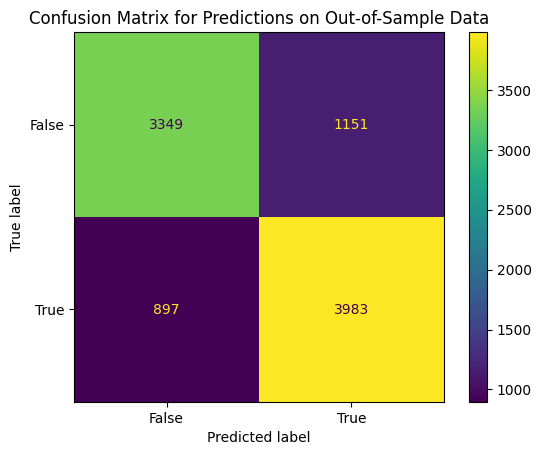

In [20]:
_, ax = plt.subplots()
metrics.ConfusionMatrixDisplay.from_estimator(model, test_X, test_y, ax=ax)
ax.set_title("Confusion Matrix for Predictions on Out-of-Sample Data")

In [21]:
conf_mat = metrics.confusion_matrix(test_y, test_pred)
conf_mat

array([[3349, 1151],
       [ 897, 3983]])

In [22]:
tn = conf_mat[0][0]
tp = conf_mat[1][1]
fp = conf_mat[0][1]
fn = conf_mat[1][0]

acc = (tn + tp) / (tn + tp + fn + fp)
sens = tp / (tp + fn)
spec = tn / (tn + fp)
prec = tp / (tp + fp)

(acc, sens, spec, prec)

(np.float64(0.7816631130063966),
 np.float64(0.8161885245901639),
 np.float64(0.7442222222222222),
 np.float64(0.775808336579665))

In [23]:
auc = metrics.roc_auc_score(test_y, test_probs[:, 1])
auc

0.8606871584699454

Text(0.5, 1.0, 'ROC Curve for Affordability: Out-of-sample AHS Data')

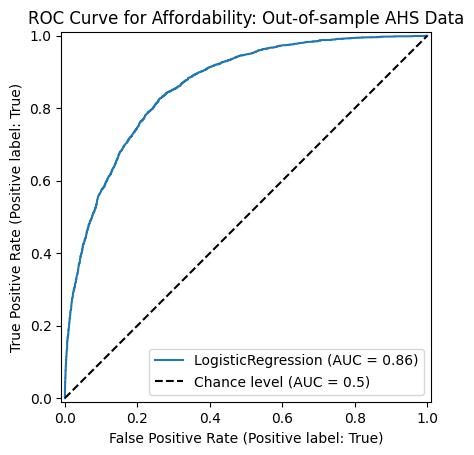

In [24]:
_, ax = plt.subplots()
metrics.RocCurveDisplay.from_estimator(model, test_X, test_y, plot_chance_level=True, ax=ax)
ax.set_title("ROC Curve for Affordability: Out-of-sample AHS Data")

In [25]:
# Look at the coefficients of all features to see which are biggest.

vr = pd.DataFrame({'COLNAME': test_X.columns, 'COEF': model.coef_[0], 'ABS_COEF': np.abs(model.coef_[0])})
vr.sort_values(by='ABS_COEF')

,COLNAME,COEF,ABS_COEF
36,AGE,0.003350,0.003350
17,BLD_04,-0.006798,0.006798
21,BLD_08,0.044671,0.044671
4,UNITSIZE_5,-0.075758,0.075758
16,BLD_03,0.078986,0.078986
20,BLD_07,0.081313,0.081313
33,UNITFLOORS_2,0.122229,0.122229
30,DIVISION_8,-0.128232,0.128232
27,DIVISION_5,0.140056,0.140056
15,BLD_02,-0.167357,0.167357


Text(0.5, 0, 'Coefficient')

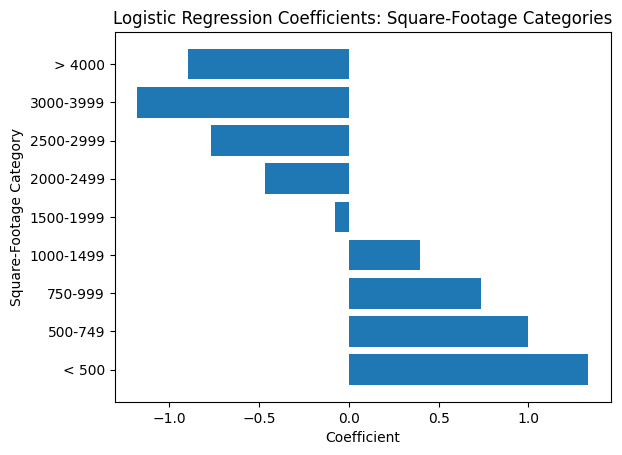

In [26]:
unitsizes = vr[vr['COLNAME'].str.contains('UNITSIZE')]
labels = ['< 500', '500-749', '750-999', '1000-1499', '1500-1999', '2000-2499', '2500-2999', '3000-3999', '> 4000']

fig, ax = plt.subplots()
ax.barh(labels, unitsizes['COEF'])
ax.set_title('Logistic Regression Coefficients: Square-Footage Categories')
plt.ylabel('Square-Footage Category')
plt.xlabel('Coefficient')

Text(0.5, 0, 'Coefficient')

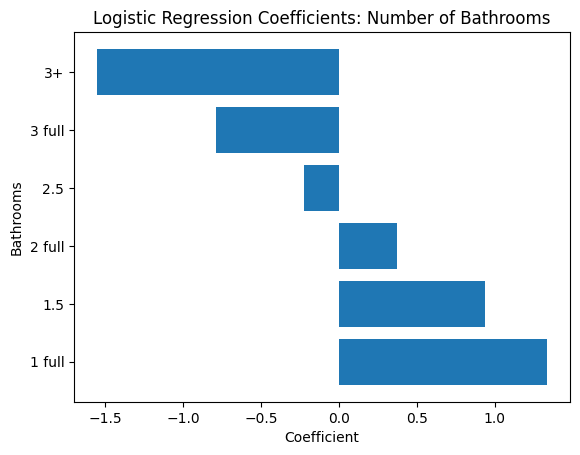

In [27]:
baths = vr[vr['COLNAME'].str.contains('BATHROOMS')]
labels = ['1 full', '1.5', '2 full', '2.5', '3 full', '3+']

fig, ax = plt.subplots()
ax.barh(labels, baths['COEF'])
ax.set_title('Logistic Regression Coefficients: Number of Bathrooms')
plt.ylabel('Bathrooms')
plt.xlabel('Coefficient')

Text(0.5, 0, 'Coefficient')

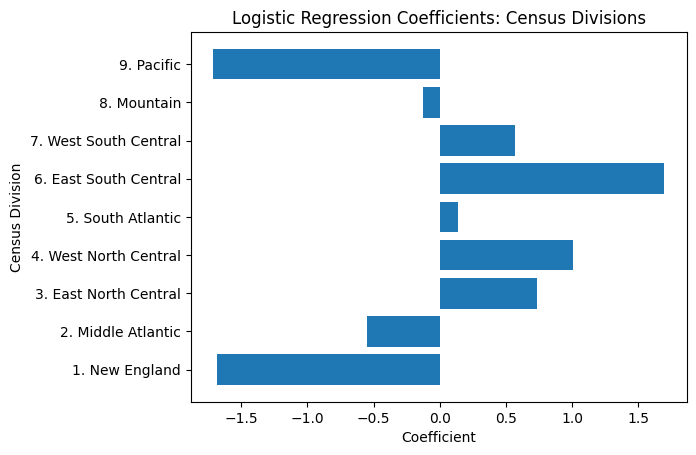

In [28]:
baths = vr[vr['COLNAME'].str.contains('DIV')]
labels = ['1. New England', '2. Middle Atlantic', '3. East North Central', '4. West North Central', '5. South Atlantic',
             '6. East South Central', '7. West South Central', '8. Mountain', '9. Pacific']

fig, ax = plt.subplots()
ax.barh(labels, baths['COEF'])
ax.set_title('Logistic Regression Coefficients: Census Divisions')
plt.ylabel('Census Division')
plt.xlabel('Coefficient')

In [29]:
# Prepare SOC data for use with logistic regression model

# Add categorical dummy variables
cat_fields = soc_df[['UNITSIZE', 'BATHROOMS', 'BLD', 'DIVISION', 'UNITFLOORS']]
other_fields = soc_df[['BEDROOMS', 'AGE']]

result = oh_enc.transform(cat_fields)

trans_cat_fields = pd.DataFrame(result, columns = oh_enc.get_feature_names_out())

soc_X = pd.concat([trans_cat_fields, other_fields], axis=1)

soc_X.dtypes

UNITSIZE_1      float64
UNITSIZE_2      float64
UNITSIZE_3      float64
UNITSIZE_4      float64
UNITSIZE_5      float64
UNITSIZE_6      float64
UNITSIZE_7      float64
UNITSIZE_8      float64
UNITSIZE_9      float64
BATHROOMS_01    float64
BATHROOMS_02    float64
BATHROOMS_03    float64
BATHROOMS_04    float64
BATHROOMS_05    float64
BATHROOMS_06    float64
BLD_02          float64
BLD_03          float64
BLD_04          float64
BLD_05          float64
BLD_06          float64
BLD_07          float64
BLD_08          float64
BLD_09          float64
DIVISION_1      float64
DIVISION_2      float64
DIVISION_3      float64
DIVISION_4      float64
DIVISION_5      float64
DIVISION_6      float64
DIVISION_7      float64
DIVISION_8      float64
DIVISION_9      float64
UNITFLOORS_1    float64
UNITFLOORS_2    float64
UNITFLOORS_3    float64
BEDROOMS          int64
AGE               int64
dtype: object

In [30]:
soc_results = model.predict(soc_X)
soc_df['AFFORDABLE'] = soc_results
soc_df['AFFORDABLE'].value_counts()

soc_df['WEIGHT'].sum()

np.int64(8766027)

In [31]:
aff_homes = soc_df[soc_df['AFFORDABLE'] == True]
non_aff_homes = soc_df[soc_df['AFFORDABLE'] == False]


In [32]:
aff_divs = aff_homes[['WEIGHT', 'DIVISION']]
non_aff_divs = non_aff_homes[['WEIGHT', 'DIVISION']]
aff_totals = aff_divs.groupby('DIVISION').sum()
non_aff_totals = non_aff_divs.groupby('DIVISION').sum()
div_tab = pd.concat([aff_totals, non_aff_totals], axis=1)
div_tab.columns=['AFFORDABLE', 'NON_AFFORDABLE']
div_tab['TOTAL'] = div_tab['AFFORDABLE'] + div_tab['NON_AFFORDABLE']
div_tab['PERCENTAGE'] = div_tab['AFFORDABLE'] / div_tab['TOTAL']
div_tab

,AFFORDABLE,NON_AFFORDABLE,TOTAL,PERCENTAGE
DIVISION,,,,
1,7779,254866,262645,0.029618
2,20438,351809,372247,0.054904
3,329119,411339,740458,0.444480
4,216658,208172,424830,0.509988
5,216903,2566136,2783039,0.077937
6,311456,182494,493950,0.630542
7,574100,1075700,1649800,0.347982
8,134073,1032848,1166921,0.114895
9,30491,841646,872137,0.034961


In [33]:
print(f'Sum affordable: {div_tab['AFFORDABLE'].sum()}')
print(f'Sum total: {div_tab['TOTAL'].sum()}')

Sum affordable: 1841017
Sum total: 8766027


In [34]:
ahs_an = df[(df['BLD'] == '02') | (df['BLD'] == '03')]

ahs_aff = ahs_an[ahs_an['AFFORDABLE'] == True]
ahs_non_aff = ahs_an[ahs_an['AFFORDABLE'] == False]

ahs_aff_counts = ahs_aff.groupby('DIVISION').sum()
ahs_non_aff_counts = ahs_non_aff.groupby('DIVISION').sum()

ahs_aff_counts = ahs_aff_counts[['WEIGHT']]
ahs_non_aff_counts = ahs_non_aff_counts[['WEIGHT']]
div_tab = pd.concat([ahs_aff_counts, ahs_non_aff_counts], axis=1)
div_tab.columns = ['AFFORDABLE', 'NON_AFFORDABLE']
div_tab['TOTAL'] = div_tab['AFFORDABLE'] + div_tab['NON_AFFORDABLE']
div_tab['PERCENTAGE'] = div_tab['AFFORDABLE'] / div_tab['TOTAL']
div_tab

,AFFORDABLE,NON_AFFORDABLE,TOTAL,PERCENTAGE
DIVISION,,,,
1,7.596251e+05,2.931921e+06,3.691546e+06,0.205774
2,3.550955e+06,5.428293e+06,8.979248e+06,0.395462
3,8.298981e+06,4.652146e+06,1.295113e+07,0.640792
4,3.736999e+06,2.388465e+06,6.125464e+06,0.610076
5,8.684547e+06,8.252652e+06,1.693720e+07,0.512750
6,3.987296e+06,1.260363e+06,5.247658e+06,0.759824
7,5.806089e+06,4.124588e+06,9.930677e+06,0.584662
8,2.396520e+06,4.097630e+06,6.494149e+06,0.369027
9,2.200684e+06,9.814207e+06,1.201489e+07,0.183163


In [35]:
sum_aff = div_tab['AFFORDABLE'].sum()
sum_total = div_tab['TOTAL'].sum()
print(f'Sum affordable: {sum_aff}')
print(f'Sum total: {sum_total}')
print(f'Overall percentage: {sum_aff / sum_total}')

Sum affordable: 39421695.02866699
Sum total: 82371957.99096857
Overall percentage: 0.478581497759095


Text(0.5, 1.0, 'Distribution of Predicted Affordable Construction by Census Division (2020-2024 SOC)')

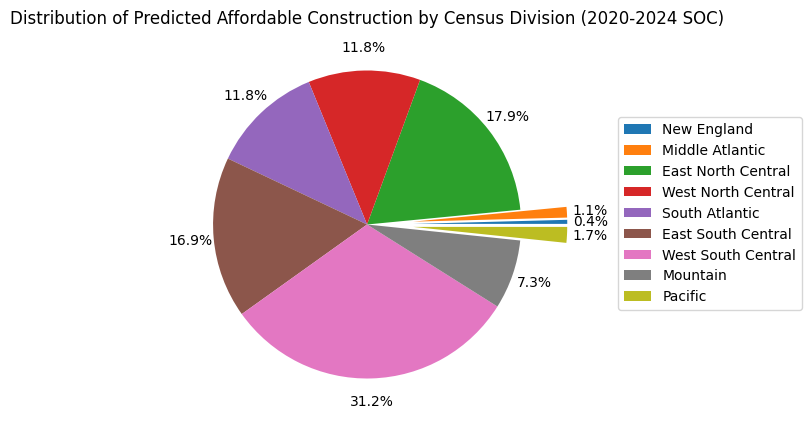

In [36]:
div_labels = ['New England', 'Middle Atlantic', 'East North Central', 'West North Central', 'South Atlantic',
             'East South Central', 'West South Central', 'Mountain', 'Pacific']

fig, ax = plt.subplots(figsize=(9, 5))
wedges, _, _ = ax.pie(aff_totals['WEIGHT'], labels=div_labels, labeldistance=None, autopct='%1.1f%%', pctdistance=1.15,
                     explode=(0.3, 0.3, 0, 0, 0, 0, 0, 0, 0.3))
fig.legend(wedges, div_labels, loc='center right')
plt.title('Distribution of Predicted Affordable Construction by Census Division (2020-2024 SOC)')

In [37]:
aff_homes['BEDROOMS'].value_counts()

BEDROOMS
3    15328
2     9340
4     1706
5       40
Name: count, dtype: int64

In [38]:
def get_count(cat, source, field):
    df = source[source[field] == cat[0]]
    return get_homecounts(df)

def get_labels(cat):
    return cat[1]

def get_counts(cats, source, field):
    counts = []
    for cat in cats:
        count = get_count(cat, source, field)
        counts.append(count)
    return counts

In [39]:
bath_cats = [('01', '1 full'), ('02', '1.5'), ('03', '2 full'), ('04', '2.5'), ('05', '3 full')]

<BarContainer object of 5 artists>

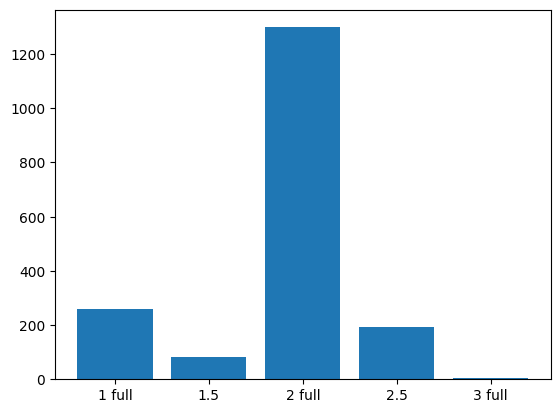

In [40]:
# Bathroom count analysis

bars = get_counts(bath_cats, aff_homes, 'BATHROOMS')
labels = [get_labels(cat) for cat in bath_cats]

fig, ax = plt.subplots()
ax.bar(labels, bars)

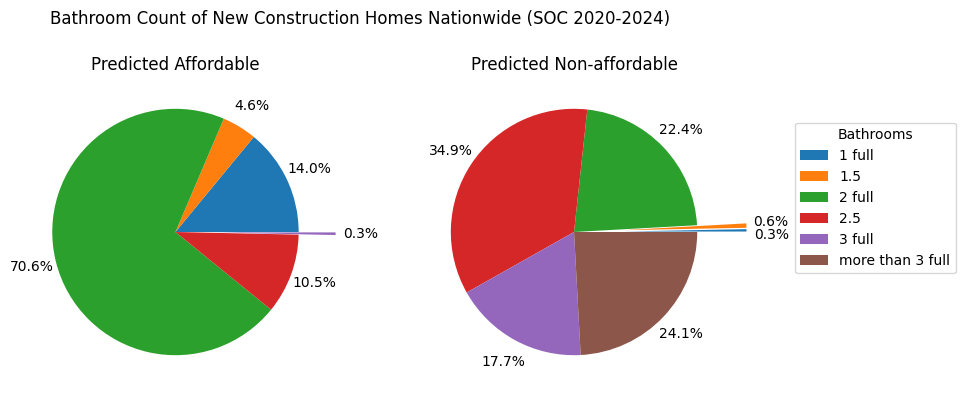

In [41]:
aff_bath_totals = aff_homes[['WEIGHT', 'BATHROOMS']].groupby('BATHROOMS').sum()
non_aff_bath_totals = non_aff_homes[['WEIGHT', 'BATHROOMS']].groupby('BATHROOMS').sum()

labels = ['1 full', '1.5', '2 full', '2.5', '3 full', 'more than 3 full']

fig, axs = plt.subplots(ncols=2, nrows=1, figsize=(12, 4))
axs[0].pie(aff_bath_totals['WEIGHT'], labels=labels[:-1], labeldistance=None, autopct='%1.1f%%', pctdistance=1.2,
      explode=(0, 0, 0, 0, 0.3))
rplot = axs[1].pie(non_aff_bath_totals['WEIGHT'], labels=labels, labeldistance=None, autopct='%1.1f%%', pctdistance=1.2,
      explode=(0.4, 0.4, 0, 0, 0, 0))
axs[0].set_title('Predicted Affordable')
axs[1].set_title('Predicted Non-affordable')
fig.legend(rplot[0], labels, loc='center right', title='Bathrooms')
fig.suptitle('Bathroom Count of New Construction Homes Nationwide (SOC 2020-2024)', y=1.05)
plt.subplots_adjust(wspace=-0.25)
rplot[2][0].set_y(-0.025)
rplot[2][1].set_y(0.08)

Text(0.5, 1.0, 'Predicted Non-affordable')

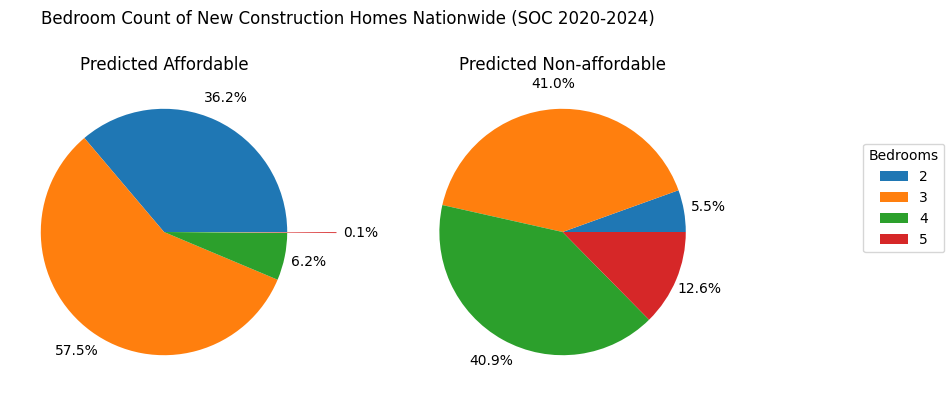

In [42]:
aff_bed_totals = aff_homes[['WEIGHT', 'BEDROOMS']].groupby('BEDROOMS').sum()
non_aff_bed_totals = non_aff_homes[['WEIGHT', 'BEDROOMS']].groupby('BEDROOMS').sum()

labels = ['2', '3', '4', '5']
fig, axs = plt.subplots(ncols=2, nrows=1, figsize=(12, 4))
axs[0].pie(aff_bed_totals['WEIGHT'], labels=labels, labeldistance=None, autopct='%1.1f%%', pctdistance=1.2,
      explode=(0, 0, 0, 0.4))
rplot = axs[1].pie(non_aff_bed_totals['WEIGHT'], labels=labels, labeldistance=None, autopct='%1.1f%%', pctdistance=1.2,
      explode=(0, 0, 0, 0))
fig.legend(wedges, labels, loc='center right', title='Bedrooms')
fig.suptitle('Bedroom Count of New Construction Homes Nationwide (SOC 2020-2024)', y=1.05)
plt.subplots_adjust(wspace=-0.25)
axs[0].set_title('Predicted Affordable')
axs[1].set_title('Predicted Non-affordable')

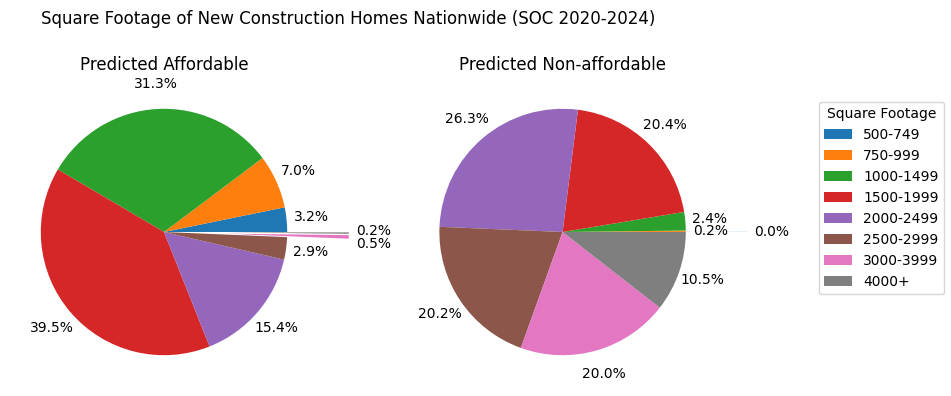

In [43]:
aff_sqft_totals = aff_homes[['WEIGHT', 'UNITSIZE']].groupby('UNITSIZE').sum()
non_aff_sqft_totals = non_aff_homes[['WEIGHT', 'UNITSIZE']].groupby('UNITSIZE').sum()

labels = ['500-749', '750-999', '1000-1499', '1500-1999', '2000-2499', '2500-2999', '3000-3999', '4000+']
fig, axs = plt.subplots(ncols=2, nrows=1, figsize=(12, 4))
lplot = axs[0].pie(aff_sqft_totals['WEIGHT'], labels=labels, labeldistance=None, autopct='%1.1f%%', pctdistance=1.2,
      explode=(0, 0, 0, 0, 0, 0, 0.5, 0.5))
rplot = axs[1].pie(non_aff_sqft_totals['WEIGHT'], labels=labels, labeldistance=None, autopct='%1.1f%%', pctdistance=1.2,
      explode=(0.5, 0, 0, 0, 0, 0, 0, 0))
fig.legend(wedges, labels, loc='center right', title='Square Footage')
fig.suptitle('Square Footage of New Construction Homes Nationwide (SOC 2020-2024)', y=1.05)
plt.subplots_adjust(wspace=-0.25)
axs[0].set_title('Predicted Affordable')
axs[1].set_title('Predicted Non-affordable')
lplot[2][-2].set_y(-0.1)
lplot[2][-1].set_y(0.01)

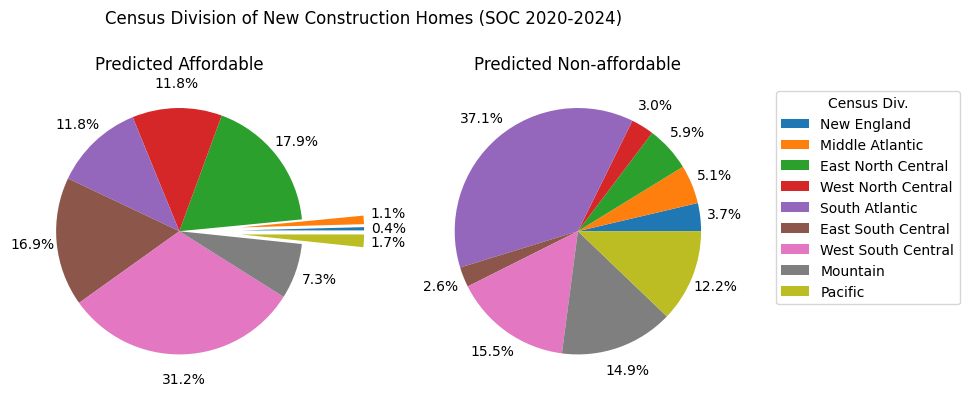

In [44]:
aff_div_totals = aff_homes[['WEIGHT', 'DIVISION']].groupby('DIVISION').sum()
non_aff_div_totals = non_aff_homes[['WEIGHT', 'DIVISION']].groupby('DIVISION').sum()

fig, axs = plt.subplots(ncols=2, nrows=1, figsize=(12, 4))
lplot = axs[0].pie(aff_div_totals['WEIGHT'], labels=div_labels, labeldistance=None, autopct='%1.1f%%', pctdistance=1.2,
      explode=(0.5, 0.5, 0, 0, 0, 0, 0, 0, 0.5))
rplot = axs[1].pie(non_aff_div_totals['WEIGHT'], labels=div_labels, labeldistance=None, autopct='%1.1f%%', pctdistance=1.2,
      explode=(0, 0, 0, 0, 0, 0, 0, 0, 0))
fig.legend(wedges, div_labels, loc='center right', title='Census Div.')
fig.suptitle('Census Division of New Construction Homes (SOC 2020-2024)', y=1.05)
plt.subplots_adjust(wspace=-0.25)
axs[0].set_title('Predicted Affordable')
axs[1].set_title('Predicted Non-affordable')
lplot[2][1].set_y(0.15)

Text(0.5, 1.0, 'Predicted Non-affordable')

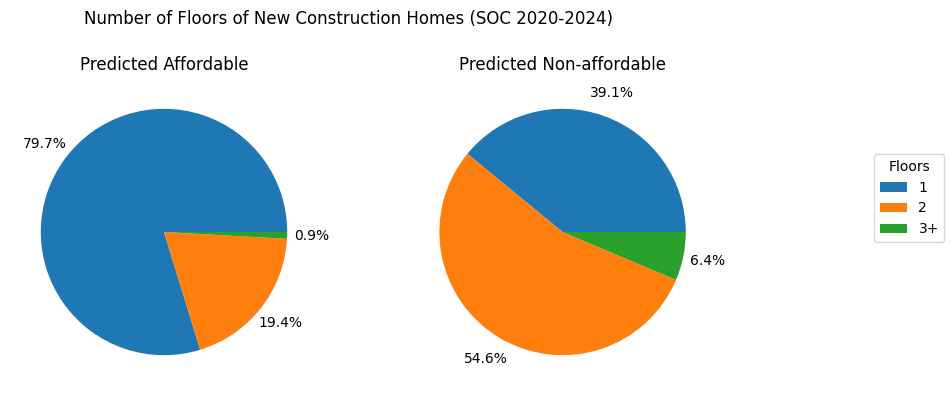

In [45]:
aff_floors_totals = aff_homes[['WEIGHT', 'UNITFLOORS']].groupby('UNITFLOORS').sum()
non_aff_floors_totals = non_aff_homes[['WEIGHT', 'UNITFLOORS']].groupby('UNITFLOORS').sum()

labels = ['1', '2', '3+']

fig, axs = plt.subplots(ncols=2, nrows=1, figsize=(12, 4))
lplot = axs[0].pie(aff_floors_totals['WEIGHT'], labels=labels, labeldistance=None, autopct='%1.1f%%', pctdistance=1.2)
rplot = axs[1].pie(non_aff_floors_totals['WEIGHT'], labels=labels, labeldistance=None, autopct='%1.1f%%', pctdistance=1.2)
fig.legend(wedges, labels, loc='center right', title='Floors')
fig.suptitle('Number of Floors of New Construction Homes (SOC 2020-2024)', y=1.05)
plt.subplots_adjust(wspace=-0.25)
axs[0].set_title('Predicted Affordable')
axs[1].set_title('Predicted Non-affordable')

Text(0.5, 1.0, 'Predicted Non-affordable')

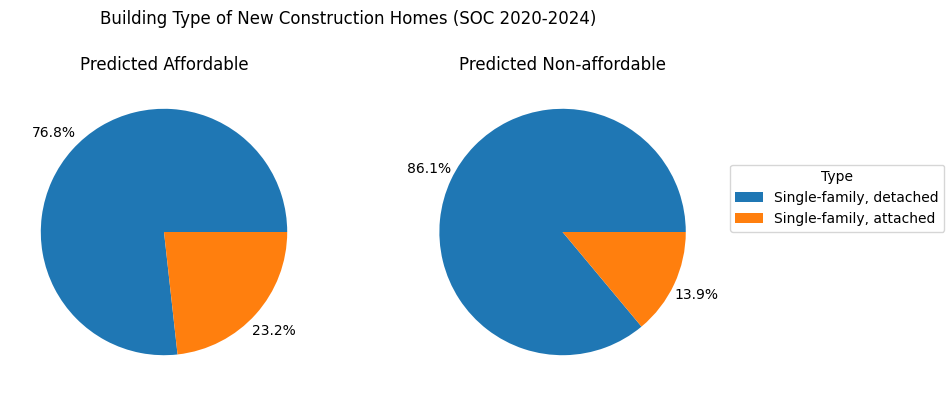

In [46]:
aff_bld_totals = aff_homes[['WEIGHT', 'BLD']].groupby('BLD').sum()
non_aff_bld_totals = non_aff_homes[['WEIGHT', 'BLD']].groupby('BLD').sum()

labels = ['Single-family, detached', 'Single-family, attached']

fig, axs = plt.subplots(ncols=2, nrows=1, figsize=(12, 4))
lplot = axs[0].pie(aff_bld_totals['WEIGHT'], labels=labels, labeldistance=None, autopct='%1.1f%%', pctdistance=1.2)
rplot = axs[1].pie(non_aff_bld_totals['WEIGHT'], labels=labels, labeldistance=None, autopct='%1.1f%%', pctdistance=1.2)
fig.legend(wedges, labels, loc='center right', title='Type')
fig.suptitle('Building Type of New Construction Homes (SOC 2020-2024)', y=1.05)
plt.subplots_adjust(wspace=-0.25)
axs[0].set_title('Predicted Affordable')
axs[1].set_title('Predicted Non-affordable')

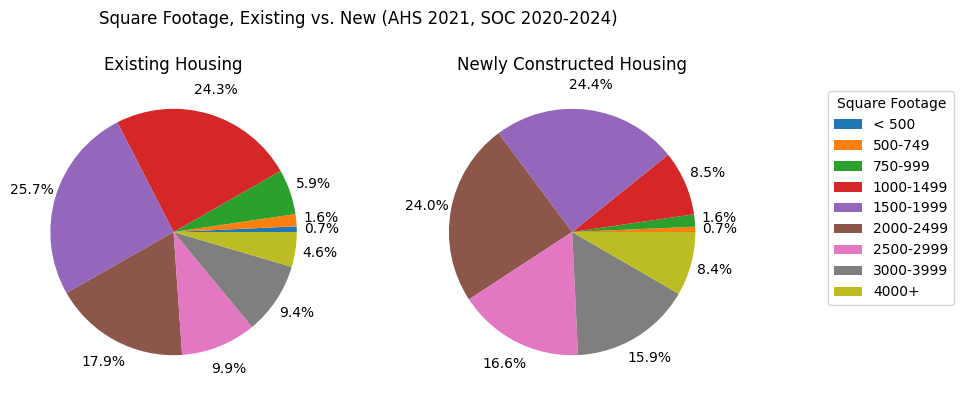

In [47]:
ext_sqft_totals = ahs_an[['WEIGHT', 'UNITSIZE']].groupby('UNITSIZE').sum()
new_sqft_totals = soc_df[['WEIGHT', 'UNITSIZE']].groupby('UNITSIZE').sum()
new_sqft_totals.loc['1'] = {'WEIGHT': 0}

new_sqft_totals.sort_index(inplace=True)
new_sqft_totals

labels = ['< 500', '500-749', '750-999', '1000-1499', '1500-1999', '2000-2499', '2500-2999', '3000-3999', '4000+']
fig, axs = plt.subplots(ncols=2, nrows=1, figsize=(12, 4))
lplot = axs[0].pie(ext_sqft_totals['WEIGHT'], labels=labels, labeldistance=None, autopct='%1.1f%%', pctdistance=1.2,
      explode=(0, 0, 0, 0, 0, 0, 0, 0, 0))
rplot = axs[1].pie(new_sqft_totals['WEIGHT'], labels=labels, labeldistance=None, autopct='%1.1f%%', pctdistance=1.2,
      explode=(0.5, 0, 0, 0, 0, 0, 0, 0, 0))
fig.legend(wedges, labels, loc='center right', title='Square Footage')
plt.subplots_adjust(wspace=-0.25)
axs[0].set_title('Existing Housing')
axs[1].set_title('Newly Constructed Housing')
fig.suptitle('Square Footage, Existing vs. New (AHS 2021, SOC 2020-2024)', y=1.05)
rplot[2][0].set_visible(False)

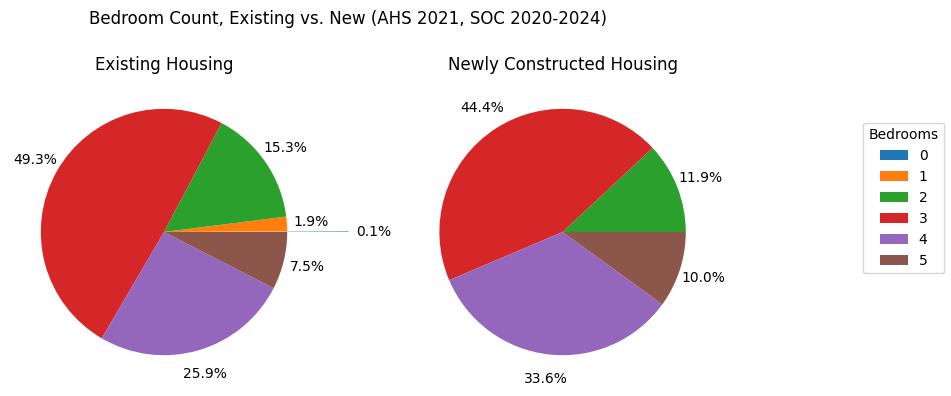

In [48]:
ext_bdr_totals = ahs_an[['WEIGHT', 'BEDROOMS']].groupby('BEDROOMS').sum()
new_bdr_totals = soc_df[['WEIGHT', 'BEDROOMS']].groupby('BEDROOMS').sum()

new_bdr_totals.loc[0] = {'WEIGHT': 0}
new_bdr_totals.loc[1] = {'WEIGHT': 0}
new_bdr_totals.sort_index(inplace=True)
new_bdr_totals

labels = ['0', '1', '2', '3', '4', '5']
fig, axs = plt.subplots(ncols=2, nrows=1, figsize=(12, 4))
lplot = axs[0].pie(ext_bdr_totals['WEIGHT'], labels=labels, labeldistance=None, autopct='%1.1f%%', pctdistance=1.2,
      explode=(0.5, 0, 0, 0, 0, 0))
rplot = axs[1].pie(new_bdr_totals['WEIGHT'], labels=labels, labeldistance=None, autopct='%1.1f%%', pctdistance=1.2,
      explode=(0, 0, 0, 0, 0, 0))
fig.legend(wedges, labels, loc='center right', title='Bedrooms')
plt.subplots_adjust(wspace=-0.25)
axs[0].set_title('Existing Housing')
axs[1].set_title('Newly Constructed Housing')
fig.suptitle('Bedroom Count, Existing vs. New (AHS 2021, SOC 2020-2024)', y=1.05)
rplot[2][0].set_visible(False)
rplot[2][1].set_visible(False)

Text(0.5, 1.05, 'Bathroom Count, Existing vs. New (AHS 2021, SOC 2020-2024)')

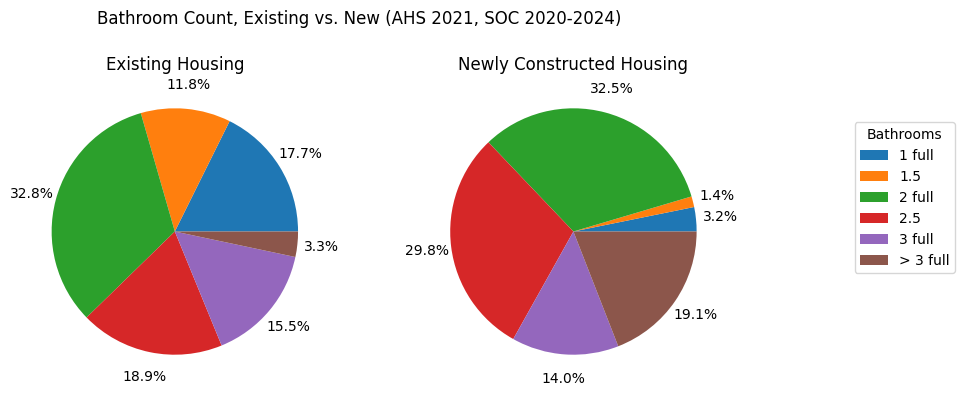

In [49]:
ext_bath_totals = ahs_an[['WEIGHT', 'BATHROOMS']].groupby('BATHROOMS').sum()
new_bath_totals = soc_df[['WEIGHT', 'BATHROOMS']].groupby('BATHROOMS').sum()

new_bath_totals

labels = ['1 full', '1.5', '2 full', '2.5', '3 full', '> 3 full']
fig, axs = plt.subplots(ncols=2, nrows=1, figsize=(12, 4))
lplot = axs[0].pie(ext_bath_totals['WEIGHT'], labels=labels, labeldistance=None, autopct='%1.1f%%', pctdistance=1.2,
      explode=(0, 0, 0, 0, 0, 0))
rplot = axs[1].pie(new_bath_totals['WEIGHT'], labels=labels, labeldistance=None, autopct='%1.1f%%', pctdistance=1.2,
      explode=(0, 0, 0, 0, 0, 0))
fig.legend(wedges, labels, loc='center right', title='Bathrooms')
plt.subplots_adjust(wspace=-0.25)
axs[0].set_title('Existing Housing')
axs[1].set_title('Newly Constructed Housing')
fig.suptitle('Bathroom Count, Existing vs. New (AHS 2021, SOC 2020-2024)', y=1.05)